In [1]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models


In [2]:

# Параметры задачи
m, n, k = 5, 5, 2  # Размер матрицы m x n с k значениями в каждой ячейке
batch_size = 32
epochs = 100

# Генерация данных
def generate_data(batch_size, m, n, k):
    # Случайные значения от -10 до 10
    X = np.random.uniform(-10, 10, size=(batch_size, m, n, k))
    # Целевые значения: возведение в квадрат
    Y = np.square(X)
    return X, Y

In [3]:


# Создание тренировочных данных
X_train, Y_train = generate_data(batch_size=1000, m=m, n=n, k=k)
X_test, Y_test = generate_data(batch_size=200, m=m, n=n, k=k)


In [4]:

# Определение модели
model = models.Sequential([
    layers.Input(shape=(m, n, k)),  # Входная форма - на самом деле хз что за слой, надо норм прогуглить + почему-то нет денс слоя в конце
    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),  # Свёрточный слой
    layers.Conv2D(k, (3, 3), activation='linear', padding='same'),  # Выходной слой
])

# Компиляция модели
model.compile(optimizer='adam', loss='mse')



In [5]:
# Обучение модели с сохранением истории
history = model.fit(
    X_train, Y_train,
    epochs=epochs,
    batch_size=16,
    validation_data=(X_test, Y_test)
)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1848.9811 - val_loss: 1463.8058
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1303.1973 - val_loss: 1021.2238
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 983.6481 - val_loss: 950.6765
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 936.9352 - val_loss: 936.6870
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 925.8329 - val_loss: 925.7731
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 907.8341 - val_loss: 914.4348
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 904.9025 - val_loss: 901.7217
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 885.0615 - val_loss: 886.6571
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 870.3019 - val_loss: 868.0457
Epoch 10/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 853.3175 - val_loss: 844.7778
Epoch 11/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 834.0689 - val_loss: 815.7279
Epoch 12/100
63

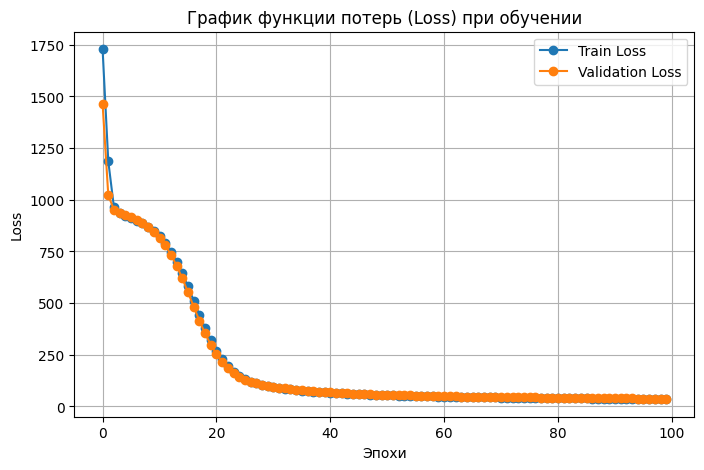

In [6]:
import matplotlib.pyplot as plt

# Построение графика лосс-функции
def plot_loss(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss', marker='o')
    plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
    plt.title('График функции потерь (Loss) при обучении')
    plt.xlabel('Эпохи')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.show()

# Вызов функции для отображения графика
plot_loss(history)

In [7]:

# Тестирование модели
X_sample, Y_sample = generate_data(batch_size=1, m=m, n=n, k=k)
Y_pred = model.predict(X_sample)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Функция для вычисления метрик
def evaluate_model(y_true, y_pred):
    # Преобразование тензоров в плоские массивы
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()

    # Расчёт метрик
    mse = mean_squared_error(y_true_flat, y_pred_flat)
    mae = mean_absolute_error(y_true_flat, y_pred_flat)
    r2 = r2_score(y_true_flat, y_pred_flat)
    r2 = r2_score(y_true_flat, y_pred_flat)

    return mse, mae, r2

# Тестирование модели
X_sample, Y_sample = generate_data(batch_size=1, m=m, n=n, k=k)
Y_pred = model.predict(X_sample)

# Расчёт метрик качества
mse, mae, r2 = evaluate_model(Y_sample[0], Y_pred[0])

# Вывод результатов
print("Метрики качества модели:")
print(f"Среднеквадратичная ошибка (MSE): {mse:.4f}")
print(f"Средняя абсолютная ошибка (MAE): {mae:.4f}")
print(f"Коэффициент детерминации (R^2): {r2:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Метрики качества модели:
Среднеквадратичная ошибка (MSE): 48.8878
Средняя абсолютная ошибка (MAE): 5.5984
Коэффициент детерминации (R^2): 0.9537


In [15]:
X1_train, Y1_train = generate_data(batch_size=2, m=3, n=3, k=2)

In [16]:
print (X1_train)

[[[[-2.12093608 -2.65358359]
   [ 7.09352708  6.48587621]
   [-9.03287137 -9.09590596]]

  [[-1.52500224  6.69927345]
   [-0.63180698  5.09406068]
   [-5.16414518  6.93249835]]

  [[-8.68156825 -6.55788944]
   [-8.89893954  3.95457795]
   [ 8.71804189  5.18334569]]]


 [[[ 2.32310361 -0.7471078 ]
   [ 9.06531618 -8.28123756]
   [ 1.94458028  9.86103534]]

  [[ 1.14176047 -6.54909694]
   [ 4.84818911 -0.26853117]
   [-8.87378811  5.74793998]]

  [[ 9.80641536  4.50897479]
   [ 1.67896485 -9.71932806]
   [-2.94111429  1.90414281]]]]
